<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/Project_5_Basic_NLP_with_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 5: Basic Natural Language Processing with Unsupervised Learning
#Name Ayleen Santander

#Part 1: Text Data Preparation
1. Load the Newsgroups dataset using scikit-learn.
2. Perform basic text preprocessing including tokenization, removing stopwords, and punctuation.

In [1]:
#Installation
%pip install ipykernel

In [41]:
#Import Libraries and dataset
import sys
print(sys.version)
print(sys.executable)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk
import re
import string
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
nltk.download("stopwords"); nltk.download("punkt")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42

STOPWORDS = set(stopwords.words("english"))
# and in preprocess(): tokens = word_tokenize(text)
from tensorflow import keras

print(tf.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
/usr/bin/python3
2.20.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
!pip install gensim

In [5]:
#1. Load Dataset
newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    random_state=42,
)

print("Number of documents:", len(newsgroups.data))
print("Number of categories:", len(newsgroups.target_names))
print("Categories:", newsgroups.target_names)

Number of documents: 11314
Number of categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [6]:
# Put it in a DataFrame for easier handling
ng = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target,
})
ng["category"] = ng["target"].apply(lambda i: newsgroups.target_names[i])

print(ng.head())

                                                text  target  \
0  I was wondering if anyone out there could enli...       7   
1  A fair number of brave souls who upgraded thei...       4   
2  well folks, my mac plus finally gave up the gh...       4   
3  \nDo you have Weitek's address/phone number?  ...       1   
4  From article <C5owCB.n3p@world.std.com>, by to...      14   

                category  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
3          comp.graphics  
4              sci.space  


In [7]:
# 2. Preprocessing function
STOPWORDS = set(ENGLISH_STOP_WORDS)
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(PUNCT_TABLE)
    # Remove numbers and extra whitespace
    text = re.sub(r"\d+", " ", text)
    # Tokenize (split into words)
    tokens = text.split()
    # Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

In [8]:
# 3. Apply preprocessing
ng["tokens"] = ng["text"].apply(preprocess)
ng["clean_text"] = ng["tokens"].apply(" ".join)

# Drop documents that became empty after cleaning
ng = ng[ng["clean_text"].str.len() > 0].reset_index(drop=True)

In [9]:
# 4. Check the results
print("\nDocuments after cleaning:", len(ng))
print("\n--- ORIGINAL ---")
print(newsgroups.data[0][:400])
print("\n--- TOKENS ---")
print(ng.loc[0, "tokens"][:30])


Documents after cleaning: 10992

--- ORIGINAL ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, h

--- TOKENS ---
['wondering', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'doors', 'really', 'small', 'addition', 'bumper', 'separate', 'rest', 'body', 'know', 'tellme', 'model', 'engine', 'specs', 'years', 'production', 'car', 'history']


In [10]:
# Top 20 most common words across the whole corpus
all_tokens = pd.Series([t for tokens in ng["tokens"] for t in tokens])
print("\nTop 20 words:")
print(all_tokens.value_counts().head(20))


Top 20 words:
people                             3997
like                               3885
dont                               3862
just                               3747
know                               3482
maxaxaxaxaxaxaxaxaxaxaxaxaxaxax    3317
use                                3161
think                              2999
time                               2800
does                               2773
new                                2571
good                               2474
make                               2022
way                                1992
used                               1865
say                                1844
right                              1810
did                                1757
said                               1739
want                               1737
Name: count, dtype: int64


#Parat 2: Text Representation
1. Implement Bag of Words and TF-IDF for feature extraction.
2. Introduce basic word embeddings and illustrate with a simple pre-trained example, if feasible.

In [11]:
#1. Toy example: see the difference on 3 short sentences
toy_docs = [
    "the car engine is fast",
    "the car has a new engine",
    "the team won the hockey game",
]

toy_bow = CountVectorizer()
toy_bow_matrix = toy_bow.fit_transform(toy_docs)
print("BAG OF WORDS (word counts):")
print(pd.DataFrame(toy_bow_matrix.toarray(),columns=toy_bow.get_feature_names_out()))

toy_tfidf = TfidfVectorizer()
toy_tfidf_matrix = toy_tfidf.fit_transform(toy_docs)
print("\nTF-IDF (weighted scores):")
print(pd.DataFrame(toy_tfidf_matrix.toarray().round(2),columns=toy_tfidf.get_feature_names_out()))

BAG OF WORDS (word counts):
   car  engine  fast  game  has  hockey  is  new  team  the  won
0    1       1     1     0    0       0   1    0     0    1    0
1    1       1     0     0    1       0   0    1     0    1    0
2    0       0     0     1    0       1   0    0     1    2    1

TF-IDF (weighted scores):
    car  engine  fast  game   has  hockey    is   new  team   the   won
0  0.41    0.41  0.53  0.00  0.00    0.00  0.53  0.00  0.00  0.32  0.00
1  0.41    0.41  0.00  0.00  0.53    0.00  0.00  0.53  0.00  0.32  0.00
2  0.00    0.00  0.00  0.43  0.00    0.43  0.00  0.00  0.43  0.51  0.43


In [12]:
# 2. Bag of Words on the full dataset
bow_vectorizer = CountVectorizer(
    max_features=5000,  # keep the 5,000 most frequent words
    min_df=5,           # ignore words appearing in fewer than 5 docs
    max_df=0.9,         # ignore words appearing in more than 90% of docs
)
X_bow = bow_vectorizer.fit_transform(ng["clean_text"])

print("\nBoW matrix shape (documents x words):", X_bow.shape)
sparsity = 1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f"Sparsity: {sparsity:.2%} of values are zero")

# Most frequent words overall
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
bow_top = pd.Series(word_counts, index=bow_vectorizer.get_feature_names_out())
print("\nTop 15 words by count:")
print(bow_top.sort_values(ascending=False).head(15))


BoW matrix shape (documents x words): (10992, 5000)
Sparsity: 99.15% of values are zero

Top 15 words by count:
people                             3997
like                               3885
dont                               3862
just                               3747
know                               3482
maxaxaxaxaxaxaxaxaxaxaxaxaxaxax    3317
use                                3161
think                              2999
time                               2800
does                               2773
new                                2571
good                               2474
make                               2022
way                                1992
used                               1865
dtype: int64


In [13]:
# 3. TF-IDF on the full dataset
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.9,
)
X_tfidf = tfidf_vectorizer.fit_transform(ng["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (10992, 5000)


In [14]:
# Top TF-IDF terms for a single document
doc_id = 0
doc_scores = pd.Series(X_tfidf[doc_id].toarray().ravel(), index=tfidf_vectorizer.get_feature_names_out())
print(f"\nDocument {doc_id} category: {ng.loc[doc_id, 'category']}")
print("Top 10 TF-IDF terms:")
print(doc_scores.sort_values(ascending=False).head(10).round(3))


Document 0 category: rec.autos
Top 10 TF-IDF terms:
car           0.577
doors         0.213
sports        0.205
production    0.201
specs         0.201
door          0.184
separate      0.180
engine        0.178
addition      0.173
late          0.171
dtype: float64


In [15]:
# Top TF-IDF terms per category (shows what makes each group distinct)
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 5 TF-IDF terms per category:")
for cat in sorted(ng["category"].unique()):
    rows = np.where(ng["category"] == cat)[0]
    mean_scores = np.asarray(X_tfidf[rows].mean(axis=0)).ravel()
    top_terms = feature_names[mean_scores.argsort()[::-1][:5]]
    print(f"{cat:<28} {', '.join(top_terms)}")


Top 5 TF-IDF terms per category:
alt.atheism                  god, people, dont, think, religion
comp.graphics                graphics, thanks, image, files, file
comp.os.ms-windows.misc      windows, file, dos, files, driver
comp.sys.ibm.pc.hardware     drive, card, scsi, controller, ide
comp.sys.mac.hardware        mac, apple, drive, thanks, problem
comp.windows.x               window, server, motif, use, thanks
misc.forsale                 sale, offer, shipping, email, condition
rec.autos                    car, cars, like, engine, just
rec.motorcycles              bike, dod, bikes, ride, motorcycle
rec.sport.baseball           year, team, baseball, game, games
rec.sport.hockey             game, team, hockey, players, games
sci.crypt                    key, encryption, clipper, chip, keys
sci.electronics              use, circuit, like, power, does
sci.med                      msg, gordon, chastity, jxp, gebcadredslpittedu
sci.space                    space, nasa, orbit, launch, mo

In [16]:
#4. Word embeddings with pre-trained GloVe vectors
glove = api.load("glove-wiki-gigaword-50")

print("\nVector for 'computer' (first 10 of 50 numbers):")
print(glove["computer"][:10].round(3))


Vector for 'computer' (first 10 of 50 numbers):
[ 0.079 -0.815  1.79   0.917  0.108 -0.556 -0.844 -1.495  0.134  0.636]


In [17]:
# Similar words: embeddings capture meaning, not just spelling
for word in ["car", "hockey", "god", "windows"]:
    similar = [w for w, _ in glove.most_similar(word, topn=5)]
    print(f"Most similar to '{word}': {similar}")

Most similar to 'car': ['truck', 'cars', 'vehicle', 'driver', 'driving']
Most similar to 'hockey': ['basketball', 'football', 'soccer', 'league', 'leagues']
Most similar to 'god': ['divine', 'heaven', 'christ', 'faith', 'allah']
Most similar to 'windows': ['window', 'console', 'desktop', 'doors', 'portable']


In [18]:
# Similarity scores (1 = identical meaning, 0 = unrelated)
print("\nSimilarity car vs automobile:", round(glove.similarity("car", "automobile"), 3))
print("Similarity car vs banana:    ", round(glove.similarity("car", "banana"), 3))


Similarity car vs automobile: 0.696
Similarity car vs banana:     0.219


In [19]:
# Classic analogy: king - man + woman = ?
result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=1)
print("\nking - man + woman =", result[0][0])


king - man + woman = queen


In [20]:
# 5. Document embeddings: average the word vectors in each post
def doc_vector(tokens, model):
    vectors = [model[t] for t in tokens if t in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


X_embed = np.vstack(ng["tokens"].apply(lambda toks: doc_vector(toks, glove)))
print("\nEmbedding matrix shape:", X_embed.shape)


Embedding matrix shape: (10992, 50)


In [21]:
# 6. Quick comparison of the three representations
summary = pd.DataFrame({
    "Method": ["Bag of Words", "TF-IDF", "GloVe average"],
    "Features": [X_bow.shape[1], X_tfidf.shape[1], X_embed.shape[1]],
    "Type": ["Sparse counts", "Sparse weights", "Dense vectors"],
    "Captures meaning?": ["No", "No", "Yes (similar words are close)"],
})
print("\n", summary.to_string(index=False))


        Method  Features           Type             Captures meaning?
 Bag of Words      5000  Sparse counts                            No
       TF-IDF      5000 Sparse weights                            No
GloVe average        50  Dense vectors Yes (similar words are close)


#Part 3: Unsupervised Learning Application
1. Apply clustering algorithms like K-Means or
2. Hierarchical Clustering to the extracted features.
3. Analyze and interpret the resulting clusters, examining common themes or topics within each cluster.

In [22]:
# 1. Choose the number of clusters (elbow + silhouette)
k_values = [5, 10, 15, 20, 25, 30]
inertias, silhouettes = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tfidf, labels, sample_size=3000,
                                        random_state=RANDOM_STATE))
    print(f"k={k:<3} inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")


k=5   inertia=10,697  silhouette=0.0038
k=10  inertia=10,580  silhouette=0.0078
k=15  inertia=10,528  silhouette=0.0087
k=20  inertia=10,464  silhouette=0.0098
k=25  inertia=10,415  silhouette=0.0106
k=30  inertia=10,365  silhouette=0.0109


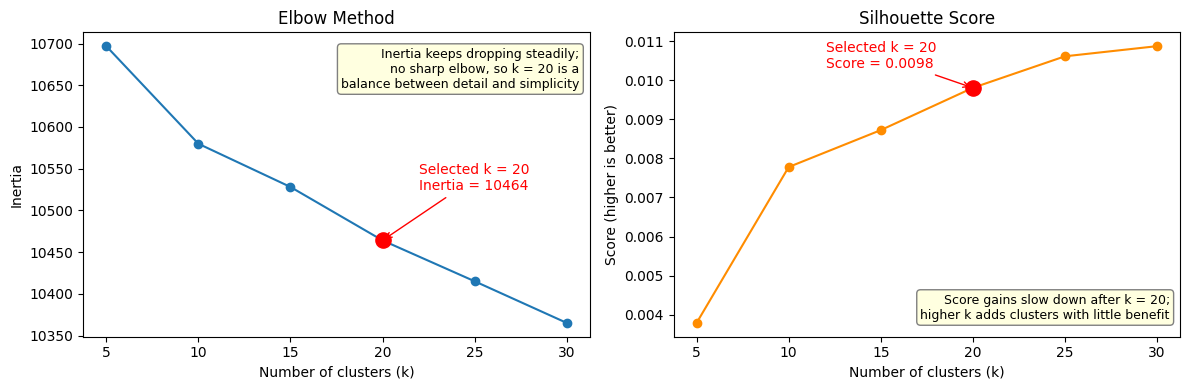

In [23]:
best_k = 20
idx = list(k_values).index(best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow chart
axes[0].plot(k_values, inertias, marker="o")
axes[0].scatter(best_k, inertias[idx], color="red", s=120, zorder=5)
axes[0].annotate(f"Selected k = {best_k}\nInertia = {inertias[idx]:.0f}",
                 xy=(best_k, inertias[idx]),
                 xytext=(best_k + 2, inertias[idx] + 60),
                 arrowprops=dict(arrowstyle="->", color="red"),
                 color="red", fontsize=10)
axes[0].text(0.98, 0.95, "Inertia keeps dropping steadily;\nno sharp elbow, so k = 20 is a\nbalance between detail and simplicity",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

# Silhouette chart
axes[1].plot(k_values, silhouettes, marker="o", color="darkorange")
axes[1].scatter(best_k, silhouettes[idx], color="red", s=120, zorder=5)
axes[1].annotate(f"Selected k = {best_k}\nScore = {silhouettes[idx]:.4f}",
                 xy=(best_k, silhouettes[idx]),
                 xytext=(best_k - 8, silhouettes[idx] + 0.0005),
                 arrowprops=dict(arrowstyle="->", color="red"),
                 color="red", fontsize=10)
axes[1].text(0.98, 0.05, "Score gains slow down after k = 20;\nhigher k adds clusters with little benefit",
             transform=axes[1].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score (higher is better)")

plt.tight_layout()
plt.show()

Explanation:
Neither chart shows a clear best k. Inertia drops steadily with no elbow, and silhouette scores stay very low (0.004–0.011), which is normal for sparse text data, where documents overlap heavily. k = 20 was chosen because it matches the 20 known newsgroups, and higher values of k added only small improvements

In [24]:
# 2. K-Means with k = 20 (matches the 20 newsgroups)
K = 20
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
ng["kmeans_cluster"] = kmeans.fit_predict(X_tfidf)

print("\nDocuments per cluster:")
print(ng["kmeans_cluster"].value_counts().sort_index())


Documents per cluster:
kmeans_cluster
0       71
1      207
2     1227
3      168
4      398
5      421
6     3042
7      253
8      392
9      250
10     524
11     282
12     788
13    1339
14     438
15     150
16     268
17     262
18     110
19     402
Name: count, dtype: int64


In [25]:
# 3. Interpret K-Means clusters: top terms per cluster
def top_terms_from_centroids(model, n_terms=10):
    order = model.cluster_centers_.argsort()[:, ::-1]
    return {c: [feature_names[i] for i in order[c, :n_terms]]
            for c in range(model.n_clusters)}


kmeans_terms = top_terms_from_centroids(kmeans)

In [26]:
# Dominant true category in each cluster
dominant = (ng.groupby("kmeans_cluster")["category"]
              .agg(lambda s: s.value_counts().index[0]))
purity = (ng.groupby("kmeans_cluster")["category"]
            .agg(lambda s: s.value_counts(normalize=True).iloc[0]))

cluster_summary = pd.DataFrame({
    "size": ng["kmeans_cluster"].value_counts().sort_index(),
    "top_terms": [", ".join(kmeans_terms[c][:8]) for c in range(K)],
    "dominant_category": dominant,
    "purity": purity.round(2),
})
pd.set_option("display.max_colwidth", 80)
print("\nK-MEANS CLUSTER SUMMARY")
print(cluster_summary.to_string())


K-MEANS CLUSTER SUMMARY
                size                                                                              top_terms         dominant_category  purity
kmeans_cluster                                                                                                                               
0                 71  gebcadredslpittedu, chastity, jxp, shameful, intellect, skepticism, surrender, gordon                   sci.med    1.00
1                207                              space, launch, nasa, lunar, orbit, moon, shuttle, station                 sci.space    0.90
2               1227                                   use, using, software, need, program, data, mhz, like            comp.windows.x    0.17
3                168                         israel, israeli, jews, arab, arabs, israelis, jewish, lebanese     talk.politics.mideast    0.97
4                398                                        car, bike, cars, engine, like, miles, new, just                

In [27]:
# 4. Compare clusters with the real categories
ari = adjusted_rand_score(ng["target"], ng["kmeans_cluster"])
nmi = normalized_mutual_info_score(ng["target"], ng["kmeans_cluster"])
print(f"\nAdjusted Rand Index: {ari:.3f}  (0 = random, 1 = perfect match)")
print(f"Normalized Mutual Info: {nmi:.3f}  (0 = no overlap, 1 = perfect match)")



Adjusted Rand Index: 0.080  (0 = random, 1 = perfect match)
Normalized Mutual Info: 0.317  (0 = no overlap, 1 = perfect match)


Note:
The clusters partly match the real categories (NMI = 0.317) but rarely line up one-to-one (ARI = 0.080). K-Means found real topics, but it merged similar groups, like the computer topics, and put some posts into mixed clusters.

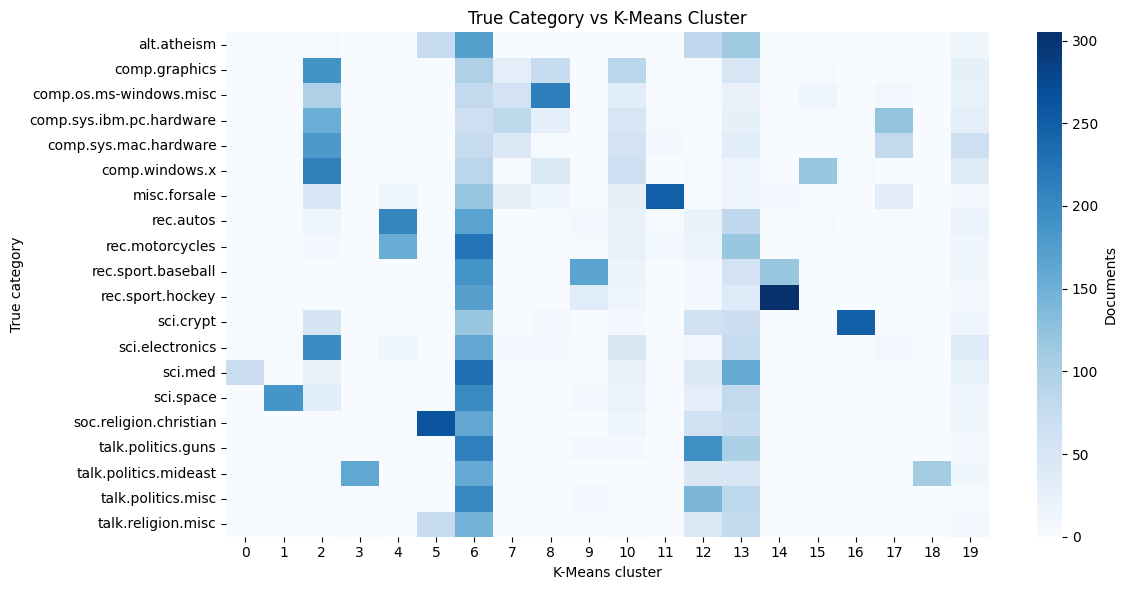

In [28]:
crosstab = pd.crosstab(ng["category"], ng["kmeans_cluster"])
plt.figure(figsize=(12, 6))
sns.heatmap(crosstab, cmap="Blues", cbar_kws={"label": "Documents"})
plt.title("True Category vs K-Means Cluster")
plt.xlabel("K-Means cluster")
plt.ylabel("True category")
plt.tight_layout(); plt.show()

Explanation:
Distinct topics such as hockey, cryptography, space, and religion formed clean clusters. Related topics like computers, vehicles, and politics merged, and clusters 6 and 13 collected generic posts from almost every category.

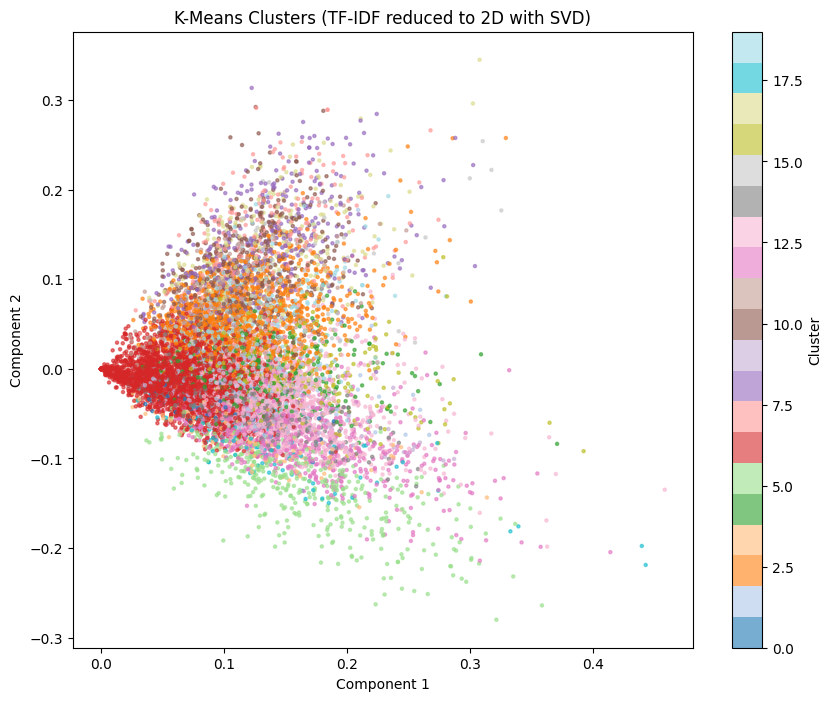

In [29]:
# 5. Visualize clusters in 2D
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd_2d.fit_transform(X_tfidf)

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=ng["kmeans_cluster"],
            cmap="tab20", s=5, alpha=0.6)
plt.title("K-Means Clusters (TF-IDF reduced to 2D with SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()

Explanation:
In 2D the clusters overlap heavily, which is expected when 5,000 features are reduced to two. The generic catch-all cluster sits near the center, while distinct topics like religion and computers spread outward in separate directions.

In [30]:
# 6. Hierarchical clustering (on a sample)
sample_idx = ng.sample(n=2000, random_state=RANDOM_STATE).index.to_numpy()
X_sample = X_tfidf[sample_idx]

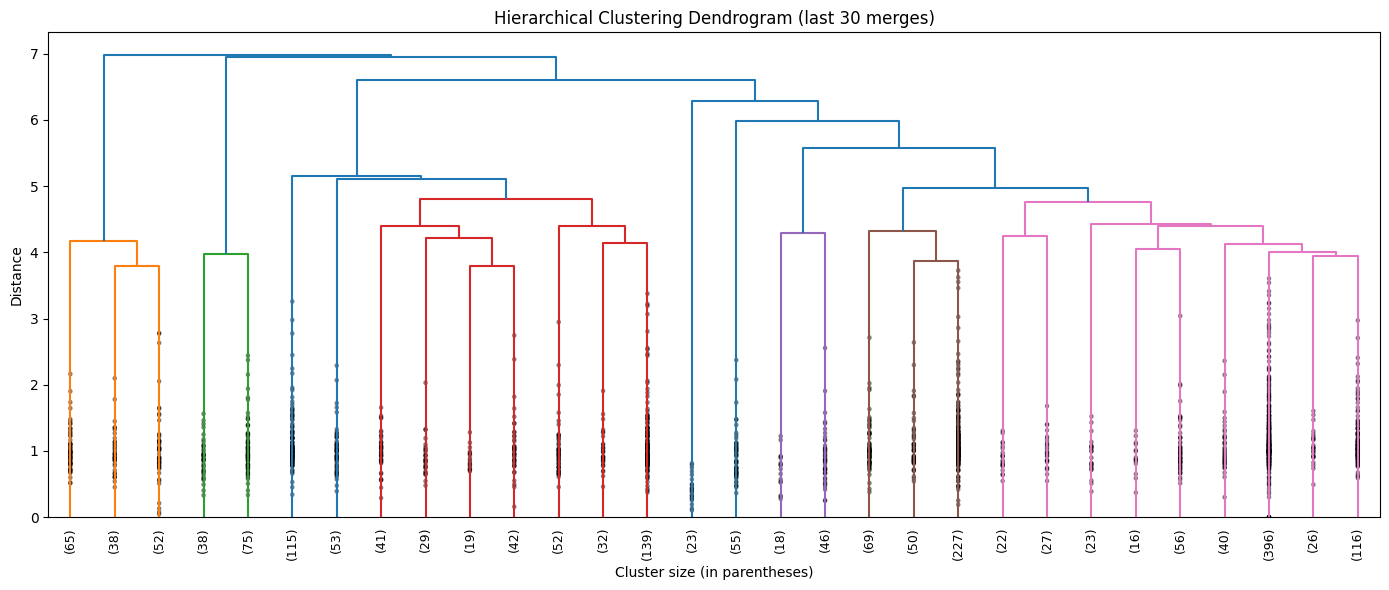

In [31]:
# Reduce to 100 dimensions first (LSA). Ward linkage needs dense data.
lsa = make_pipeline(TruncatedSVD(n_components=100, random_state=RANDOM_STATE),
                    Normalizer(copy=False))
X_sample_lsa = lsa.fit_transform(X_sample)

Z = linkage(X_sample_lsa, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (last 30 merges)")
plt.xlabel("Cluster size (in parentheses)")
plt.ylabel("Distance")
plt.tight_layout(); plt.show()

In [32]:
# Cut the tree into 20 clusters
sample_ng = ng.loc[sample_idx, ["category", "target"]].copy()
sample_ng["hier_cluster"] = fcluster(Z, t=K, criterion="maxclust")

In [33]:
# 7. Interpret hierarchical clusters
hier_rows = []
for c in sorted(sample_ng["hier_cluster"].unique()):
    positions = np.where(sample_ng["hier_cluster"].to_numpy() == c)[0]
    mean_scores = np.asarray(X_sample[positions].mean(axis=0)).ravel()
    top = feature_names[mean_scores.argsort()[::-1][:8]]
    cats = sample_ng.iloc[positions]["category"].value_counts(normalize=True)
    hier_rows.append({
        "cluster": c,
        "size": len(positions),
        "top_terms": ", ".join(top),
        "dominant_category": cats.index[0],
        "purity": round(cats.iloc[0], 2),
    })

hier_summary = pd.DataFrame(hier_rows).set_index("cluster")
print("\nHIERARCHICAL CLUSTER SUMMARY (2,000-doc sample)")
print(hier_summary.to_string())

hier_nmi = normalized_mutual_info_score(sample_ng["target"], sample_ng["hier_cluster"])
print(f"\nHierarchical NMI (sample): {hier_nmi:.3f}")


HIERARCHICAL CLUSTER SUMMARY (2,000-doc sample)
         size                                                                              top_terms         dominant_category  purity
cluster                                                                                                                               
1         155                                     game, team, year, season, play, games, fans, teams        rec.sport.baseball    0.44
2         113                             god, church, jesus, bible, christian, faith, people, think    soc.religion.christian    0.57
3         115                          thanks, does, information, anybody, know, code, info, advance            comp.windows.x    0.17
4          53                              drive, scsi, tape, controller, drives, floppy, ide, cdrom  comp.sys.ibm.pc.hardware    0.43
5          41                             windows, dos, version, unix, use, microsoft, works, thanks   comp.os.ms-windows.misc    0.44
6     

In [34]:
# 8. Bonus: K-Means on GloVe document embeddings
X_embed_norm = Normalizer().fit_transform(X_embed)
kmeans_embed = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
ng["embed_cluster"] = kmeans_embed.fit_predict(X_embed_norm)
embed_nmi = normalized_mutual_info_score(ng["target"], ng["embed_cluster"])

In [35]:
# 9. Final comparison
results = pd.DataFrame({
    "Method": ["K-Means + TF-IDF", "Hierarchical (Ward) + LSA", "K-Means + GloVe"],
    "Docs": [len(ng), len(sample_ng), len(ng)],
    "NMI vs true labels": [round(nmi, 3), round(hier_nmi, 3), round(embed_nmi, 3)],
})
print("\n", results.to_string(index=False))


                    Method  Docs  NMI vs true labels
         K-Means + TF-IDF 10992               0.317
Hierarchical (Ward) + LSA  2000               0.314
          K-Means + GloVe 10992               0.333


#Part 4: Model Evaluation and Prediction
1. Demonstrate the applicability of the clustering model to new, unseen documents to predict their cluster assignments.
2. Validate the effectiveness of the model by examining how well new documents fit into the established clusters using metrics such as silhouette score or cohesion and separation measures.

In [36]:
# 1. Predict clusters for a few hand-written documents
new_docs = [
    "The goalie made an amazing save in the third period and the team won the playoff game.",
    "NASA launched a new satellite into orbit to study the moon and the solar system.",
    "My graphics card driver keeps crashing when I run Windows. Should I reinstall it?",
    "The government should not restrict the right to own firearms.",
    "Encryption keys and the clipper chip raise serious privacy concerns.",
]

def predict_cluster(texts):
    cleaned = [" ".join(preprocess(t)) for t in texts]
    X_new = tfidf_vectorizer.transform(cleaned)
    labels = kmeans.predict(X_new)
    distances = kmeans.transform(X_new)  # distance to every centroid
    return X_new, labels, distances


X_custom, custom_labels, custom_dist = predict_cluster(new_docs)

print("PREDICTIONS FOR NEW DOCUMENTS\n")
for text, label, dist in zip(new_docs, custom_labels, custom_dist):
    nearest, second = np.sort(dist)[:2]
    print(f"Text: {text[:70]}...")
    print(f"  Cluster {label} | theme: {', '.join(kmeans_terms[label][:6])}")
    print(f"  Closest training category: {dominant[label]}")
    print(f"  Distance to centroid: {nearest:.3f} (next closest: {second:.3f})\n")

PREDICTIONS FOR NEW DOCUMENTS

Text: The goalie made an amazing save in the third period and the team won t...
  Cluster 14 | theme: game, team, games, players, hockey, play
  Closest training category: rec.sport.hockey
  Distance to centroid: 0.962 (next closest: 1.001)

Text: NASA launched a new satellite into orbit to study the moon and the sol...
  Cluster 1 | theme: space, launch, nasa, lunar, orbit, moon
  Closest training category: sci.space
  Distance to centroid: 0.970 (next closest: 0.998)

Text: My graphics card driver keeps crashing when I run Windows. Should I re...
  Cluster 7 | theme: card, video, drivers, monitor, cards, driver
  Closest training category: comp.sys.ibm.pc.hardware
  Distance to centroid: 0.920 (next closest: 0.968)

Text: The government should not restrict the right to own firearms....
  Cluster 12 | theme: people, government, think, dont, gun, just
  Closest training category: talk.politics.guns
  Distance to centroid: 0.995 (next closest: 1.000)

Text

In [37]:
# 2. Load the official test set (documents the model never saw)
test = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes"),
    random_state=RANDOM_STATE,
)
test_new = pd.DataFrame({"text": test.data, "target": test.target})
test_new["category"] = test_new["target"].apply(lambda i: test.target_names[i])
test_new["clean_text"] = test_new["text"].apply(lambda t: " ".join(preprocess(t)))
test_new = test_new[test_new["clean_text"].str.len() > 0].reset_index(drop=True)

X_test = tfidf_vectorizer.transform(test_new["clean_text"])
test_new["cluster"] = kmeans.predict(X_test)
print("Test documents:", len(test_new))

Test documents: 7296


In [38]:
# Cohesion   = distance to its own cluster centroid (smaller = tighter)
# Separation = distance to the nearest OTHER centroid (larger = better)
# Fit score  = (separation - cohesion) / max(both)
#              ranges -1 to 1, like a simplified silhouette.
def cohesion_separation(X, labels):
    dist = kmeans.transform(X)
    rows = np.arange(len(labels))
    cohesion = dist[rows, labels]
    dist_other = dist.copy()
    dist_other[rows, labels] = np.inf
    separation = dist_other.min(axis=1)
    fit = (separation - cohesion) / np.maximum(separation, cohesion)
    return cohesion, separation, fit


train_labels = ng["kmeans_cluster"].to_numpy()
test_labels = test_new["cluster"].to_numpy()

tr_coh, tr_sep, tr_fit = cohesion_separation(X_tfidf, train_labels)
te_coh, te_sep, te_fit = cohesion_separation(X_test, test_labels)
test_new["cohesion"], test_new["separation"], test_new["fit_score"] = te_coh, te_sep, te_fit

In [39]:
# 4. Standard clustering metrics: train vs test
# Silhouette uses a sample for speed. Davies-Bouldin and
# Calinski-Harabasz need dense arrays.
def sample_rows(X, labels, n=3000):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=min(n, X.shape[0]), replace=False)
    return X[idx], labels[idx]


Xs_tr, ls_tr = sample_rows(X_tfidf, train_labels)
Xs_te, ls_te = sample_rows(X_test, test_labels)

metrics = pd.DataFrame({
    "Metric": [
        "Silhouette (higher better)",
        "Davies-Bouldin (lower better)",
        "Calinski-Harabasz (higher better)",
        "Mean cohesion (lower better)",
        "Mean separation (higher better)",
        "Mean fit score (higher better)",
        "NMI vs true labels",
        "ARI vs true labels",
    ],
    "Train": [
        silhouette_score(Xs_tr, ls_tr),
        davies_bouldin_score(Xs_tr.toarray(), ls_tr),
        calinski_harabasz_score(Xs_tr.toarray(), ls_tr),
        tr_coh.mean(), tr_sep.mean(), tr_fit.mean(),
        normalized_mutual_info_score(ng["target"], train_labels),
        adjusted_rand_score(ng["target"], train_labels),
    ],
    "Test (unseen)": [
        silhouette_score(Xs_te, ls_te),
        davies_bouldin_score(Xs_te.toarray(), ls_te),
        calinski_harabasz_score(Xs_te.toarray(), ls_te),
        te_coh.mean(), te_sep.mean(), te_fit.mean(),
        normalized_mutual_info_score(test_new["target"], test_labels),
        adjusted_rand_score(test_new["target"], test_labels),
    ],
})
metrics["Train"] = metrics["Train"].round(4)
metrics["Test (unseen)"] = metrics["Test (unseen)"].round(4)
print("\nTRAIN vs TEST METRICS")
print(metrics.to_string(index=False))


TRAIN vs TEST METRICS
                           Metric  Train  Test (unseen)
       Silhouette (higher better) 0.0087         0.0046
    Davies-Bouldin (lower better) 8.2536         7.9985
Calinski-Harabasz (higher better) 6.3438         5.3642
     Mean cohesion (lower better) 0.9732         0.9780
  Mean separation (higher better) 0.9910         0.9909
   Mean fit score (higher better) 0.0192         0.0144
               NMI vs true labels 0.3174         0.2844
               ARI vs true labels 0.0800         0.0632


Note:
Test metrics closely matched training metrics (NMI 0.317 vs 0.284), showing the clusters generalize to unseen documents. However, cohesion and separation were nearly equal (0.97 vs 0.99), and silhouette stayed near zero, confirming the clusters overlap heavily.

In [42]:
# 5. Per-cluster fit on test documents
test_sil = silhouette_samples(Xs_te, ls_te)
sil_by_cluster = pd.Series(test_sil).groupby(ls_te).mean()

per_cluster = pd.DataFrame({
    "theme": [", ".join(kmeans_terms[c][:5]) for c in range(kmeans.n_clusters)],
    "train_share": pd.Series(train_labels).value_counts(normalize=True).sort_index(),
    "test_share": pd.Series(test_labels).value_counts(normalize=True).sort_index(),
    "test_cohesion": test_new.groupby("cluster")["cohesion"].mean(),
    "test_fit_score": test_new.groupby("cluster")["fit_score"].mean(),
    "test_silhouette": sil_by_cluster,
}).round(3)
print("\nPER-CLUSTER FIT ON TEST DATA")
print(per_cluster.sort_values("test_fit_score", ascending=False).to_string())


PER-CLUSTER FIT ON TEST DATA
                                                     theme  train_share  test_share  test_cohesion  test_fit_score  test_silhouette
0   gebcadredslpittedu, chastity, jxp, shameful, intellect        0.006       0.000          0.863           0.133            0.000
18           armenian, armenians, turkish, armenia, turkey        0.010       0.008          0.906           0.085            0.088
17                          drive, scsi, drives, hard, ide        0.024       0.023          0.940           0.048            0.047
3                       israel, israeli, jews, arab, arabs        0.015       0.011          0.946           0.045            0.043
15              window, application, manager, motif, xterm        0.014       0.008          0.948           0.039            0.056
5                        god, jesus, bible, faith, believe        0.038       0.036          0.953           0.034            0.031
16                    key, encryption, chip, c

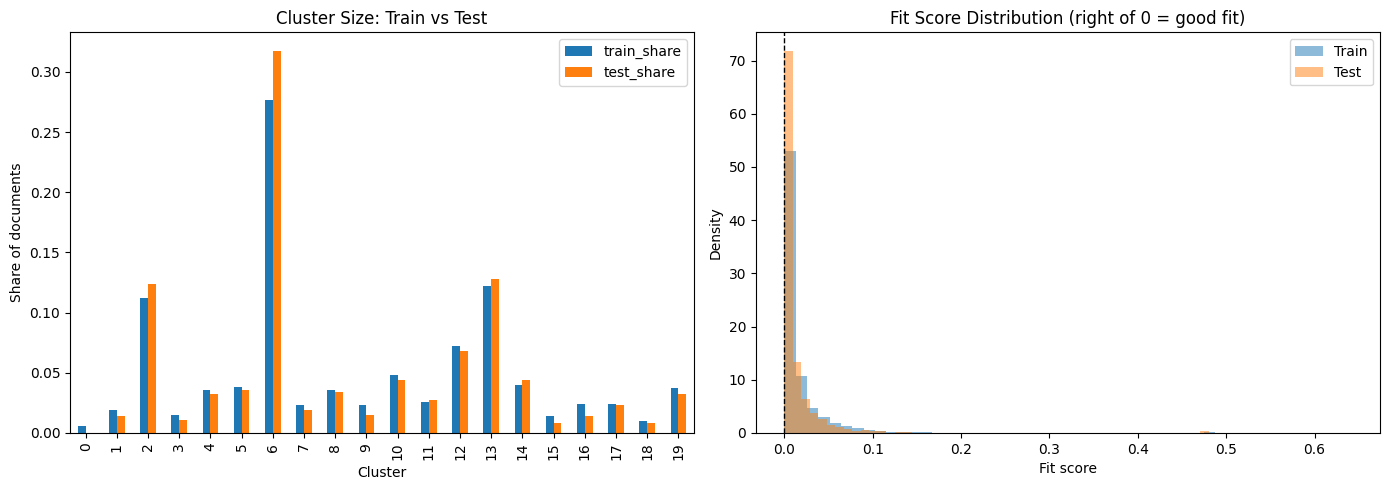

In [43]:
# 6. Visual checks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Are clusters used in the same proportions on new data?
per_cluster[["train_share", "test_share"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Cluster Size: Train vs Test")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Share of documents")

# b) How well do documents fit their clusters?
axes[1].hist(tr_fit, bins=50, alpha=0.5, density=True, label="Train")
axes[1].hist(te_fit, bins=50, alpha=0.5, density=True, label="Test")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Fit Score Distribution (right of 0 = good fit)")
axes[1].set_xlabel("Fit score")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

Explanation:
Cluster sizes were nearly identical between train and test, though more unseen posts fell into the catch-all cluster (28% → 32%). Fit scores were mostly just above zero, meaning documents fit their clusters only slightly better than neighbouring ones.

In [44]:
# 7. Best and worst fitting test documents
def show_examples(frame, title):
    print(f"\n{title}")
    for _, row in frame.iterrows():
        print(f"  [cluster {row['cluster']} | fit {row['fit_score']:.3f} | "
              f"true: {row['category']}] {row['text'][:100].strip()!r}")


ranked = test_new.sort_values("fit_score")
show_examples(ranked.tail(5)[::-1], "BEST-FITTING TEST DOCUMENTS")
show_examples(ranked.head(5), "WORST-FITTING TEST DOCUMENTS")

weak_share = (test_new["fit_score"] < 0.05).mean()
print(f"\nShare of test docs with a weak fit (score < 0.05): {weak_share:.1%}")


BEST-FITTING TEST DOCUMENTS
  [cluster 6 | fit 0.480 | true: sci.crypt] 'csrc.ncsl.nist.gov (129.6.54.11) is ftp-able from here...'
  [cluster 6 | fit 0.480 | true: comp.windows.x] 'please subscrive me.'
  [cluster 6 | fit 0.480 | true: alt.atheism] 'It is still incestuous.... :)'
  [cluster 6 | fit 0.480 | true: rec.motorcycles] 'Polysyllabic is polysyllabic too....'
  [cluster 6 | fit 0.480 | true: rec.autos] 'cheek.'

WORST-FITTING TEST DOCUMENTS
  [cluster 13 | fit 0.000 | true: sci.electronics] 'Can someone tell me where to find 120volt 3 watt 40 mA fans that\nfit the standard computer mounting'
  [cluster 9 | fit 0.000 | true: rec.sport.baseball] 'With all the recent problems the Indians have been having\nwith their pitching staff I have heard num'
  [cluster 12 | fit 0.000 | true: sci.crypt] ">in the field who might be able to find out haven't yet done their\n >review of the chip design, and"
  [cluster 13 | fit 0.000 | true: rec.sport.baseball] 'According to an article in the 

Explanation:
The highest fit scores came from near-empty posts with no vocabulary words, which defaulted to the catch-all cluster, so they are an artifact rather than true good fits. The lowest-scoring posts were real topical posts sitting between overlapping clusters. With 94.4% of test documents scoring below 0.05, most documents fit their cluster only weakly.